# KL divergence computation for MGD on jet data 

In [1]:
import torch
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import to_rgb
from pathlib import Path
import sys
import copy
from types import SimpleNamespace

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_experiment import * 
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

sys.path.insert(0, str(root / '../turbulence/'))
from diagnostics import * 

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/jets


In [2]:
# Default parameters
J = 8
Q = 1
M = 256
sigma = 3.5
n1 = 5000

nt = 20000
Re_number = 929
lam = 1e-07
n_subsample = 100
regularization = 1e-3

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

# VITESSE MODANE DATA 
from scipy.io import loadmat
data = loadmat("../data/data_files/helium_jets/Vit_Modane95.mat")
Data = data["Vit"].squeeze(1) 
Data = torch.from_numpy(Data[None,None,:]).float().to(device) 
print(Data.shape, Data.device) 

n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)
print(Data.shape) 

torch.Size([1, 1, 25803816]) cuda:0
torch.Size([25199, 1, 1024])


In [3]:
Data = Data[:n1,:,:]
B, C, L = Data.shape

for j in range(2):
    Data = W.decompose(Data)[1]

print(Data.shape) 

torch.Size([5000, 1, 256])


In [4]:
x1 = normalize(Data).to(device)
print(x1.mean(), x1.std())
print('x1 shape:', x1.shape)

tensor(2.2583e-07, device='cuda:0') tensor(1.0000, device='cuda:0')
x1 shape: torch.Size([5000, 1, 256])


In [5]:
terms=[
    "L_6", 
    "Scattering_First_Order", 
    "Scattering_Second_Order", 
    "Scattering_Fourth_Order_Mod2_Real_Q1", 
    "Scattering_Fourth_Order_Mod2_Imag_Q1"
]
base_args = SimpleNamespace(
    Re_number=Re_number,
    J=J,
    Q=Q,
    terms=terms, 
    nt=nt,
    sigma=sigma,
    interpolant='Cos',
    regularization=regularization,
    lam=lam,
    n_subsample=n_subsample,
    batch_size="", # Adjust based on your x1.shape[0] // 2
    label="",
    timestamp="",    # Leave empty to allow the resolver to find the latest run
    n1=n1,     
)

In [6]:
experiments_to_compare = {
    f'seed{i}': {"seed": i} for i in range(50)
}

In [7]:
import gc
import torch
import os 
import re 


# Assuming `results` already exists or you want to start fresh:
if 'results' not in locals() and 'results' not in globals():
    results = {}

pattern = re.compile(
    r"^jetsynth_Re_number929_M256_J8_Q1_sigma3\.5_nt20000_n1_5000_lam1e-07_seed_(\d+)_terms6d216e41_20260717_0036$"
)

print("Scanning directory once...")
# 2. Grab all directory contents just once to avoid heavy repetitive disk lookups
all_folders = os.listdir(os.path.join(root, "saved_results/samples"))
# 1. Define the 4 separate chunk ranges
chunks = [
    range(0, 13),   # 0 to 12
    range(13, 25),  # 13 to 24
    range(25, 38),  # 25 to 37
    range(38, 49)   # 38 to 49
]

# 2. Run chunk by chunk
for chunk_idx, seed_range in enumerate(chunks, 1):
    print(f"=== PROCESSING CHUNK {chunk_idx}/4 (Seeds {seed_range.start} to {seed_range.stop - 1}) ===")
    
    # Filter matching runs for this specific sub-range
    current_chunk_runs = {}
    for folder in all_folders:
        match = pattern.match(folder)
        if match:
            seed_val = int(match.group(1))
            if seed_val in seed_range:
                current_chunk_runs[f"seed{seed_val}"] = folder
                
    # Keys you actually want to keep
    KEYS_TO_KEEP = {'xt', 'theta_t', 'Theta_reg', 'dH_t_bound', 't'}
    
    for key, resolved_config in sorted(current_chunk_runs.items(), key=lambda x: int(x[0].replace("seed", ""))):
        print(f"  [{key}] Loading: {resolved_config}")
        loaded_data = try_load_experiment(root, resolved_config, device)
        
        if loaded_data and loaded_data.get('loaded', False):
            # Create a lightweight dict containing ONLY your target keys
            filtered_data = {k: loaded_data[k] for k in KEYS_TO_KEEP if k in loaded_data}
            
            # Save only the filtered version
            results[key] = filtered_data
            
            # Explicitly clear the giant original dict from memory immediately
            del loaded_data
        else:
            print(f"    -> Warning: Failed to read data for {key}")

    print(f"=== CHUNK {chunk_idx} FINISHED. Current results size: {len(results)} ===")
    
    # 3. Force memory cleanup before starting the next chunk
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
print(f"\nAll chunks processed successfully! Total items in results: {len(results)}")

Scanning directory once...
=== PROCESSING CHUNK 1/4 (Seeds 0 to 12) ===
  [seed0] Loading: jetsynth_Re_number929_M256_J8_Q1_sigma3.5_nt20000_n1_5000_lam1e-07_seed_0_terms6d216e41_20260717_0036
  [seed1] Loading: jetsynth_Re_number929_M256_J8_Q1_sigma3.5_nt20000_n1_5000_lam1e-07_seed_1_terms6d216e41_20260717_0036
  [seed2] Loading: jetsynth_Re_number929_M256_J8_Q1_sigma3.5_nt20000_n1_5000_lam1e-07_seed_2_terms6d216e41_20260717_0036
  [seed3] Loading: jetsynth_Re_number929_M256_J8_Q1_sigma3.5_nt20000_n1_5000_lam1e-07_seed_3_terms6d216e41_20260717_0036
  [seed4] Loading: jetsynth_Re_number929_M256_J8_Q1_sigma3.5_nt20000_n1_5000_lam1e-07_seed_4_terms6d216e41_20260717_0036
  [seed5] Loading: jetsynth_Re_number929_M256_J8_Q1_sigma3.5_nt20000_n1_5000_lam1e-07_seed_5_terms6d216e41_20260717_0036
  [seed6] Loading: jetsynth_Re_number929_M256_J8_Q1_sigma3.5_nt20000_n1_5000_lam1e-07_seed_6_terms6d216e41_20260717_0036
  [seed7] Loading: jetsynth_Re_number929_M256_J8_Q1_sigma3.5_nt20000_n1_5000_lam1

In [8]:
# Coarse-grain or analyze the experiments
for key, res in results.items():
    theta_t = res['theta_t']
    theta_reg_t = res['Theta_reg'] # Updated to match the new return dictionary
    
    print(f"{key}:")
    print(f"  theta_t shape: {theta_t.shape}", f"  Theta_reg shape: {theta_reg_t.shape}")
    #print("is theta reg Nan?", theta_reg_t[:5,5])     

seed0:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed1:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed2:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed3:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed4:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed5:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed6:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed7:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed8:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed9:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166])
seed10:
  theta_t shape: torch.Size([19869, 166])   Theta_reg shape: torch.Size([197, 166]

## For Etienne: save the last value of the runs of theta

In [9]:
# ------------------------------------------------------------------
# Extract final-time feature vectors for Theta_reg and theta_MGD per seed
# Shape assumed: (time, features) -> take [-1, :] to get all features at final time
# ------------------------------------------------------------------
final_theta_reg = {}   # seed_int -> tensor/array of shape (features,)
final_theta_MGD = {}   # seed_int -> tensor/array of shape (features,)

for key, data in results.items():
    seed_val = int(key.replace("seed", ""))

    if 'Theta_reg' not in data:
        print(f"  [WARNING] {key}: no Theta_reg found, skipping")
        continue
    if 'theta_t' not in data:
        print(f"  [WARNING] {key}: no theta_t found, skipping")
        continue

    theta_reg = data['Theta_reg']
    theta_MGD = data['theta_t']

    # Move to CPU tensors if needed
    if torch.is_tensor(theta_reg):
        theta_reg = theta_reg.detach().cpu()
    if torch.is_tensor(theta_MGD):
        theta_MGD = theta_MGD.detach().cpu()

    # (time, features) -> take last time step, keep all features
    final_reg_vals = theta_reg[-1, :]
    final_mgd_vals = theta_MGD[-1, :]

    final_theta_reg[seed_val] = final_reg_vals
    final_theta_MGD[seed_val] = final_mgd_vals

seeds_sorted = sorted(final_theta_reg.keys())
n_features_reg = len(final_theta_reg[seeds_sorted[0]]) if seeds_sorted else 0
n_features_mgd = len(final_theta_MGD[seeds_sorted[0]]) if seeds_sorted else 0

print(f"\nCollected final-time feature vectors for {len(seeds_sorted)} seeds: "
      f"Theta_reg has {n_features_reg} features, theta_MGD has {n_features_mgd} features.")

# --- Save as a torch .pt file (preserves tensors, easiest round-trip) ---
save_path_pt = os.path.join(root, "saved_results", "final_theta_JETS_comparison.pt")
torch.save({
    "seeds": seeds_sorted,
    "theta_reg_final": final_theta_reg,   # dict: seed -> tensor of shape (features,)
    "theta_MGD_final": final_theta_MGD,   # dict: seed -> tensor of shape (features,)
}, save_path_pt)
print(f"Saved torch summary to: {save_path_pt}")

# --- Save as CSV: one row per seed, columns for each feature of each tensor ---
import numpy as np
import csv

save_path_csv = os.path.join(root, "saved_results", "final_theta_JETS_comparison.csv")
with open(save_path_csv, "w", newline="") as f:
    writer = csv.writer(f)
    header = (
        ["seed"]
        + [f"theta_reg_{i}" for i in range(n_features_reg)]
        + [f"theta_MGD_{i}" for i in range(n_features_mgd)]
    )
    writer.writerow(header)

    for seed_val in seeds_sorted:
        reg_vals = final_theta_reg[seed_val]
        mgd_vals = final_theta_MGD[seed_val]

        reg_np = reg_vals.numpy() if torch.is_tensor(reg_vals) else np.asarray(reg_vals)
        mgd_np = mgd_vals.numpy() if torch.is_tensor(mgd_vals) else np.asarray(mgd_vals)

        writer.writerow([seed_val] + reg_np.tolist() + mgd_np.tolist())

print(f"Saved CSV comparison to: {save_path_csv}")


Collected final-time feature vectors for 49 seeds: Theta_reg has 166 features, theta_MGD has 166 features.
Saved torch summary to: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/jets/saved_results/final_theta_JETS_comparison.pt
Saved CSV comparison to: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/jets/saved_results/final_theta_JETS_comparison.csv


## Noise to signal analysis 

In [21]:
# ------------------------------------------------------------
# Compute theta column ranges for each potential
# ------------------------------------------------------------
sizes = {k: p.num_coefficients for k, p in potentials.items()}

potential_ranges = {}
start = 0
for name, dim in sizes.items():
    potential_ranges[name] = (start, start + dim)
    start += dim

print(potential_ranges)
potential_colors = {
    "L_6": "tab:blue",
    "Scattering_First_Order": "tab:orange",
    "Scattering_Second_Order": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
}

{'L_6': (0, 9), 'Scattering_First_Order': (9, 17), 'Scattering_Second_Order': (17, 26), 'Scattering_Fourth_Order_Mod2_Real_Q1': (26, 110), 'Scattering_Fourth_Order_Mod2_Imag_Q1': (110, 166)}


In [22]:
import os
import pandas as pd

# ------------------------------------------------------------
# Load saved file
# ------------------------------------------------------------
load_path = os.path.join(root, "saved_results", "final_theta_JETS_comparison.pt")
data = torch.load(load_path, map_location="cpu")

seeds = data["seeds"]

theta_reg = np.stack([
    data["theta_reg_final"][s].numpy()
    for s in seeds
])

theta_mgd = np.stack([
    data["theta_MGD_final"][s].numpy()
    for s in seeds
])

print("Theta_reg shape :", theta_reg.shape)
print("Theta_MGD shape :", theta_mgd.shape)

n_seeds, n_features = theta_reg.shape

Theta_reg shape : (49, 166)
Theta_MGD shape : (49, 166)


In [23]:
eps = 1e-12

stats = {}

for name, X in {
    "Theta_reg": theta_reg,
    "Theta_MGD": theta_mgd,
}.items():

    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    var = std**2

    cv = std / (np.abs(mean) + eps)

    rel_var = var / (mean**2 + eps)

    snr = np.abs(mean) / (std + eps)

    stats[name] = dict(
        mean=mean,
        std=std,
        var=var,
        cv=cv,
        rel_var=rel_var,
        snr=snr,
    )

,Theta_reg mean variance,Theta_MGD mean variance,Theta_reg median variance,Theta_MGD median variance,Theta_reg mean CV,Theta_MGD mean CV,Theta_reg mean SNR,Theta_MGD mean SNR
0,3.895729e+10,3.260223e+12,5.294410e+09,5.378716e+11,28.744179,29.304703,2.268224,0.344051


Mean correlation : 0.11228490838591962
Median correlation : 0.12106449381588733


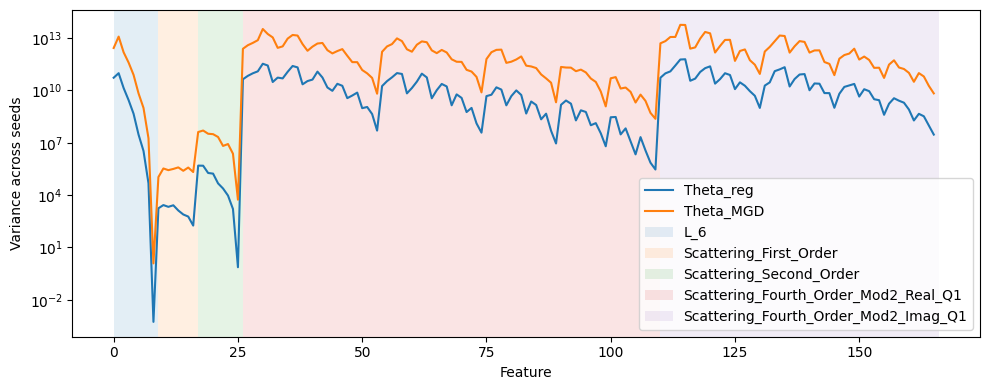

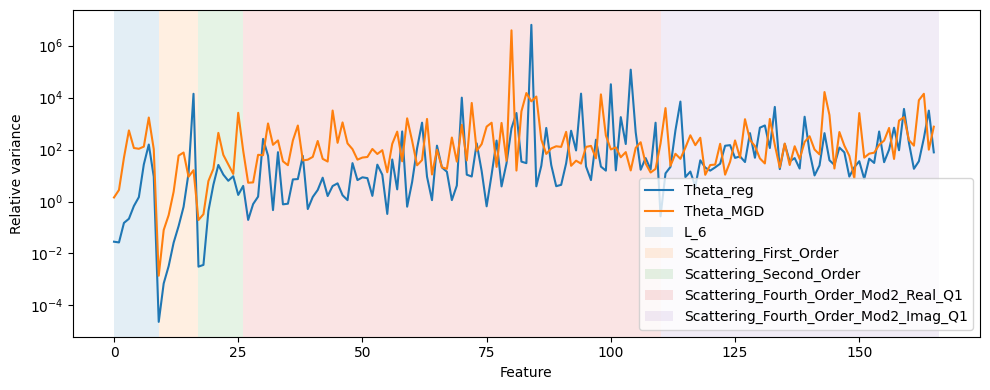

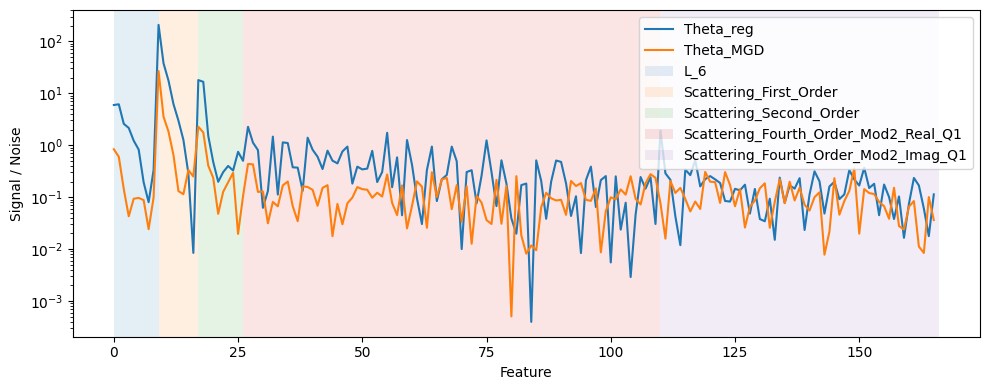

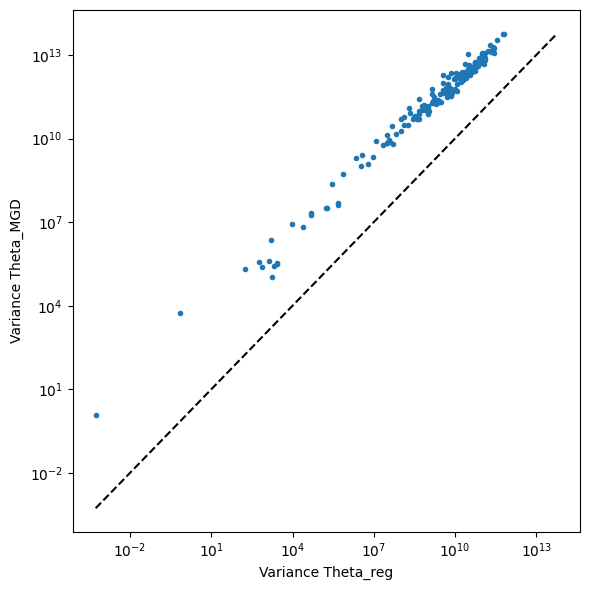

Largest Theta_reg variances
115 613275530000.0
114 592128440000.0
30 338666880000.0
31 267905370000.0
113 267404180000.0
36 252109180000.0
120 240605020000.0
135 215109290000.0
37 209375440000.0
119 189120040000.0

Largest Theta_MGD variances
114 57524498000000.0
115 56710643000000.0
30 33230233000000.0
119 22528288000000.0
120 18773745000000.0
31 17162794000000.0
36 15127194000000.0
134 14051946000000.0
37 14013811000000.0
135 13202318000000.0


In [24]:
summary = pd.DataFrame({
    "Theta_reg mean variance": [stats["Theta_reg"]["var"].mean()],
    "Theta_MGD mean variance": [stats["Theta_MGD"]["var"].mean()],

    "Theta_reg median variance": [np.median(stats["Theta_reg"]["var"])],
    "Theta_MGD median variance": [np.median(stats["Theta_MGD"]["var"])],

    "Theta_reg mean CV": [stats["Theta_reg"]["cv"].mean()],
    "Theta_MGD mean CV": [stats["Theta_MGD"]["cv"].mean()],

    "Theta_reg mean SNR": [stats["Theta_reg"]["snr"].mean()],
    "Theta_MGD mean SNR": [stats["Theta_MGD"]["snr"].mean()],
})

display(summary)
corrs = []

for j in range(n_features):
    c = np.corrcoef(theta_reg[:, j], theta_mgd[:, j])[0,1]
    corrs.append(c)

corrs = np.array(corrs)

print("Mean correlation :", np.nanmean(corrs))
print("Median correlation :", np.nanmedian(corrs))

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Variance across seeds")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["rel_var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["rel_var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Relative variance")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.plot(stats["Theta_reg"]["snr"], label="Theta_reg")
plt.plot(stats["Theta_MGD"]["snr"], label="Theta_MGD")
plt.yscale("log") 
plt.xlabel("Feature")
plt.ylabel("Signal / Noise")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))

plt.loglog(
    stats["Theta_reg"]["var"],
    stats["Theta_MGD"]["var"],
    "."
)

xmin = min(
    stats["Theta_reg"]["var"].min(),
    stats["Theta_MGD"]["var"].min()
)
xmax = max(
    stats["Theta_reg"]["var"].max(),
    stats["Theta_MGD"]["var"].max()
)

plt.plot([xmin,xmax],[xmin,xmax],"k--")

plt.xlabel("Variance Theta_reg")
plt.ylabel("Variance Theta_MGD")
plt.tight_layout()
plt.show()

idx = np.argsort(stats["Theta_reg"]["var"])[::-1]

print("Largest Theta_reg variances")
for i in idx[:10]:
    print(i, stats["Theta_reg"]["var"][i])

print()

idx = np.argsort(stats["Theta_MGD"]["var"])[::-1]

print("Largest Theta_MGD variances")
for i in idx[:10]:
    print(i, stats["Theta_MGD"]["var"][i])

## KL divergence 

In [9]:
import math

def compute_expected_kl_divergence(theta_runs, phi_X):
    """
    E_runs[ log E_X[ exp(-(theta_n - theta_star)^T phi(X)) ] ]

    Args:
        theta_runs: [N_runs, T, 166]
        phi_X:      [B, 166]
        theta_star: [T, 166] or [166] -- TRUE target theta, NOT mean(theta_runs)
    """
    if isinstance(theta_runs, list):
        theta_runs = torch.stack(theta_runs)

    N_runs, T, num_params = theta_runs.shape
    B, num_features = phi_X.shape
    assert num_params == num_features

    kl_divergence_t = torch.zeros(T, device=theta_runs.device, dtype=torch.float64)
    log_B = math.log(B)

    for n in range(N_runs):
        theta_n = theta_runs[n]                       # [T, 166]
        theta_star = theta_runs.mean(dim=0)   # ASSUMPTION! computing around the average value 
        negative_delta_theta = -(theta_n - theta_star) # [T, 166]
        dot_product = torch.matmul(negative_delta_theta, phi_X.T)  # [T, B]

        # numerically stable log(mean(exp(dot_product)))
        log_inner = torch.logsumexp(dot_product.double(), dim=1) - log_B  # [T]
        kl_divergence_t += log_inner

    kl_divergence_t /= N_runs
    return kl_divergence_t.to(theta_runs.dtype)

In [16]:
with torch.no_grad():
    # 1. Initialize the filters and the potential objects
    filters = return_Filters(M, J, 1, device=device) 
    potentials = get_1d_potentials(
        terms, J, filters, Q,
        scalar_param=None, parallel=False,
    )
    
    # Use .values() to access the actual Potential objects, not the string keys
    sizes = [p.num_coefficients for p in potentials.values()]
    print(f"Total potential features: {sum(sizes)}") # Should print 166
    
    # 2. Evaluate your actual dataset X through each potential
    evaluated_features = []
    
    # Again, use .values() to loop through the modules
    for p in potentials.values():
        p.to(device)
        
        # Note: If your framework uses p.fit(X) instead of the forward pass p(X) 
        # to return the statistics, swap this out!
        feat = p(x1) 
        
        # Ensure it's 2D: [B, num_coefficients] before appending
        if feat.ndim == 1:
            feat = feat.unsqueeze(1)
            
        evaluated_features.append(feat)
        
    # 3. Concatenate all computed features into the final phi_X matrix
    phi_X = torch.cat(evaluated_features, dim=-1)


# 2. Extract the theta trajectories from the results dict
print("Extracting MGD trajectories...")
theta_t_list = [results[key]['theta_t'].to(device) for key in results.keys()]

print("Extracting Regularized trajectories...")
theta_reg_list = [results[key]['Theta_reg'].to(device) for key in results.keys()]

print(len(theta_t_list), len(theta_reg_list)) 

Total potential features: 166
Extracting MGD trajectories...
Extracting Regularized trajectories...
49 49


In [17]:
phi_X.shape 

torch.Size([5000, 166])

In [18]:
# 3. Compute the KL divergences over time
print("Computing KL divergence for MGD...")
kl_mgd = compute_expected_kl_divergence(theta_t_list, phi_X).cpu() 
print(kl_mgd.shape) 
kl_mgd[:10]

Computing KL divergence for MGD...


<class 'NameError'>: name 'compute_expected_kl_divergence' is not defined

In [13]:
print("Computing KL divergence for Regularized...")
kl_reg = compute_expected_kl_divergence(theta_reg_list, phi_X).cpu() 
print(kl_reg.shape) 
kl_reg[:10]

Computing KL divergence for Regularized...
torch.Size([197])


tensor([2129394.5000, 1439230.8750,  759385.9375,  465752.3125,  244745.2812,
         143721.6562,  113763.4297,   65569.1797,   44347.0898,   31537.8008])

Last value of KL for MGD and REG: 1348.171630859375, 57.84625244140625
Cramer-Rao bound: 0.0166


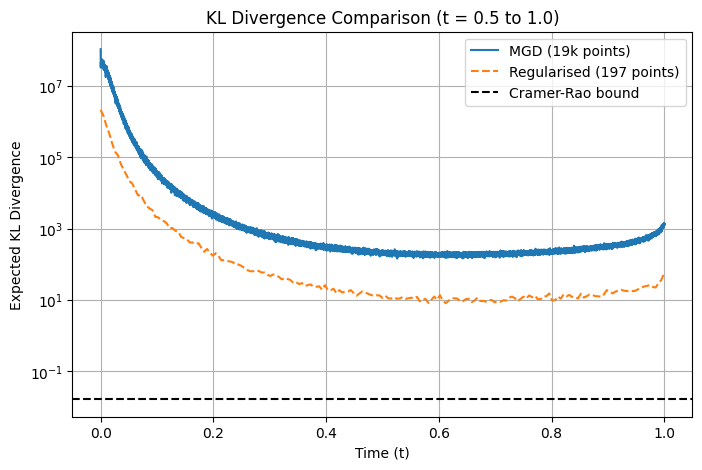

In [18]:
kl_mgd_np = kl_mgd.detach().cpu().numpy()
kl_reg_np = kl_reg.detach().cpu().numpy()

print(f"Last value of KL for MGD and REG: {kl_mgd_np[-1]}, {kl_reg_np[-1]}")
print(f"Cramer-Rao bound: {phi_X.shape[1] / (2*n1)}") 

# 2. Build your time arrays
t_mgd = np.linspace(0, 1, len(kl_mgd_np))
t_reg = np.linspace(0, 1, len(kl_reg_np))

# 3. Create a mask for the time span [0.5, 1.0]
mask_mgd = t_mgd >= 0.0
mask_reg = t_reg >= 0.0

%matplotlib inline
# 4. Plot the matched time intervals
plt.figure(figsize=(8, 5))
plt.plot(t_mgd[mask_mgd], kl_mgd_np[mask_mgd], label="MGD (19k points)")
plt.plot(t_reg[mask_reg], kl_reg_np[mask_reg], label="Regularised (197 points)", linestyle="--")

plt.axhline(phi_X.shape[1] / (2*n1), color="black", linestyle="--", label="Cramer-Rao bound") 

plt.xlabel("Time (t)")
plt.ylabel("Expected KL Divergence")
plt.yscale("log") 
plt.title("KL Divergence Comparison (t = 0.5 to 1.0)")
plt.legend()
plt.grid(True)
plt.show()

## Normalising constant 

In [20]:
import re

def _sigma_from_label(label: str) -> float:
    """Extract the numeric sigma value from a label like 'sigma = 20.0'."""
    m = re.search(r'sigma\s*=\s*([0-9.]+)', label)
    if m is None:
        raise ValueError(f"Could not parse sigma from label: {label!r}")
    return float(m.group(1))


def _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point):
    """Final-time entropy bound H_sigma* = H(p_0) + cumulative integral of dH."""
    dH_t_bound = dH_t_bound.detach().cpu()
    t_used = t_used.detach().cpu()
    nt_val = nt if nt is not None else t_used.shape[0]

    d = x_ref.shape[-2] * x_ref.shape[-1]
    H_p_0 = (np.log(2 * np.pi) + 1) * d / 2
    H_t_bound_full = dH_t_bound.cumsum(0) / nt_val + H_p_0

    # Guard against dH_t_bound/t length mismatch (same issue as plot_entropy_curves)
    min_len = min(t_used.shape[0], H_t_bound_full.shape[0])
    H_final = H_t_bound_full[min_len - last_point].item()
    return H_p_0, H_final, d


def plot_negentropy_convergence(
    x_ref: torch.Tensor,
    results: Dict[str, Dict],
    last_point=1,
    nt: Optional[int] = None,
) -> pd.DataFrame:
    """
    Reproduce Fig. 7 style plots across a sweep of sigma experiments:
      (a) ΔH_σ* = H(p_0) - H_σ*         vs sigma^2
      (b) d^-1 (H_σmax* - H_σ*)         vs sigma^2, log-log, with sigma^-2 reference
    Requires >=2 experiments, each with a 'sigma = <value>' label.
    """
    sigmas, H_finals, ds = [], [], []
    H_p_0 = None
    for key, res in results.items():
        sigma_val = _sigma_from_label(key)
        t_used = results[key]['t']
        dH_t_bound = results[key]['dH_t_bound']
        print(dH_t_bound) 
        H_p_0, H_final, d = _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point)
        sigmas.append(sigma_val)
        H_finals.append(H_final)
        ds.append(d)

    sigmas = np.array(sigmas)
    H_finals = np.array(H_finals)
    d = ds[0]  # assumes same dimensionality across all experiments

    order = np.argsort(sigmas)
    sigmas, H_finals = sigmas[order], H_finals[order]
    sigma2 = sigmas ** 2
    negentropy = H_p_0 - H_finals

    # Reference run: largest sigma in the sweep
    idx_max = np.argmax(sigmas)
    H_max = H_finals[idx_max]
    conv = np.abs(H_max - H_finals) / d

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # (a) negentropy vs sigma^2
    axes[0].plot(sigma2, negentropy, 'o--', color='tab:blue')
    axes[0].set_xlabel(r'$\sigma^2$')
    axes[0].set_ylabel(r'$\Delta H_*^\sigma$')
    axes[0].set_title('Negentropy estimate')
    axes[0].grid(True, ls=':', alpha=0.4)

    # (b) convergence vs sigma_max, log-log (drop the sigma_max point: diff = 0)
    mask = np.arange(len(sigmas)) != idx_max
    axes[1].loglog(sigma2[mask], conv[mask], 'o', color='tab:blue', label='data')

    x_line = np.geomspace(sigma2[mask].min(), sigma2[mask].max(), 50)
    c = conv[mask][0] * sigma2[mask][0] ** 2  # anchor sigma^-2 line to first point
    #axes[1].plot(x_line, c / x_line ** 2, '-', color='tab:blue',linewidth=1.5, label=r'$\sigma^{-2}$')

    axes[1].set_xlabel(r'$\sigma^2$')
    axes[1].set_ylabel(r'$d^{-1}(H_*^{\sigma_{\max}} - H_*^\sigma)$')
    axes[1].set_title(fr'Convergence ($\sigma^2_{{\max}}$={sigma2[idx_max]:.2g})')
    axes[1].legend(frameon=False, fontsize=9)
    axes[1].grid(True, which='both', ls=':', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        'sigma': sigmas, 'sigma2': sigma2,
        'H_final': H_finals, 'negentropy': negentropy,
        'convergence': conv,
    })

def compute_m1(xt, potentials, device):
    """
    m1 = E_{p_theta_1}[phi] estimated from final-time particles xt.
    xt: [B, ...] e.g. [5000, 1, 256]
    """
    xt = xt.to(device)
    feats = []
    with torch.no_grad():
        for p in potentials.values():
            p.to(device)
            f = p(xt)
            if f.ndim == 1:
                f = f.unsqueeze(1)
            feats.append(f)
    phi_xt = torch.cat(feats, dim=-1)   # [B, 166]
    return phi_xt.mean(dim=0)           # [166]


def compute_log_Z_sigma(x_ref, results, key, theta_key, potentials, device, nt=None, last_point=1):
    """
    log Z_sigma = H_final - theta_1^T m_1

    Args:
        key:       results dict key for the sigma=3.5 run (from _sigma_from_label)
        theta_key: 'theta_t' for MGD or 'Theta_reg' for REG
    """
    dH_t_bound = results[key]['dH_t_bound']
    t_used = results[key]['t']
    _, H_final, _ = _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point)

    theta_1 = results[key][theta_key][-1].to(device)  # [166]
    xt = results[key]['xt']                            # [5000, 1, 256]
    m1 = compute_m1(xt, potentials, device)             # [166]

    log_Z_sigma = H_final - (theta_1 @ m1).item()
    return log_Z_sigma, m1

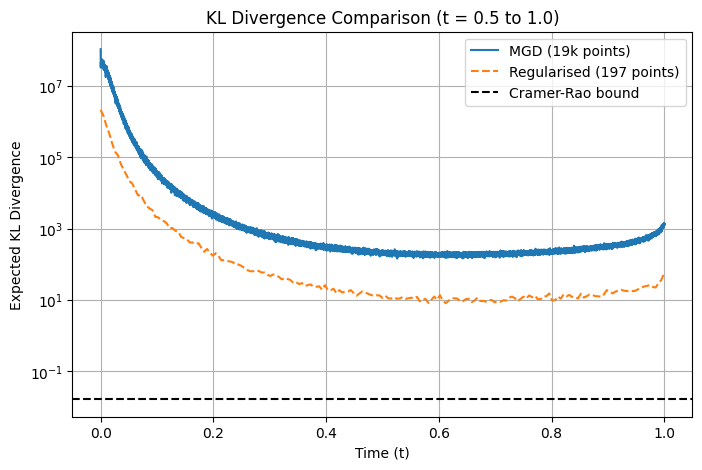

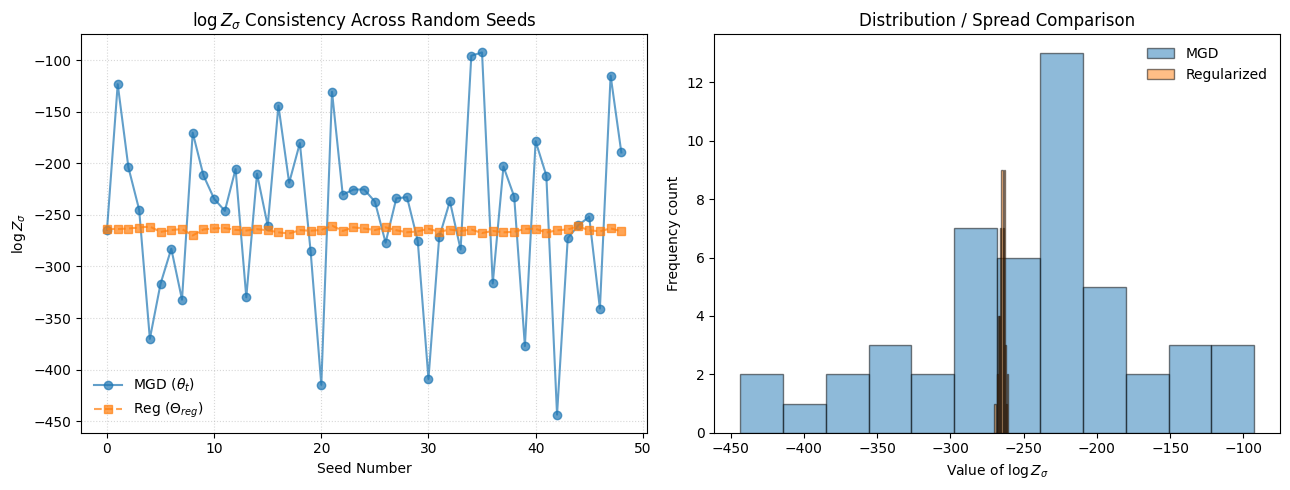

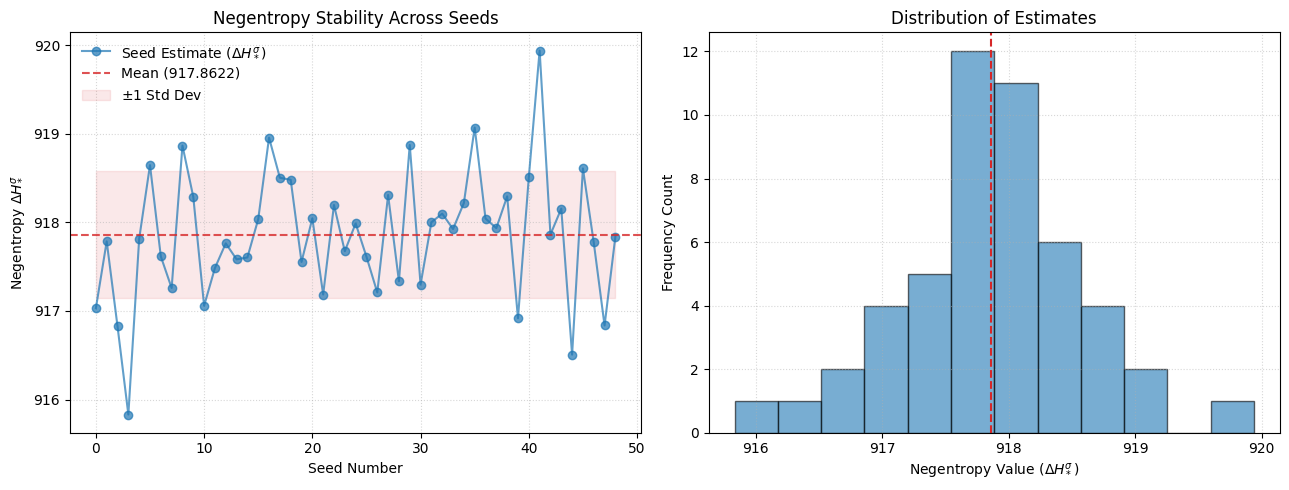

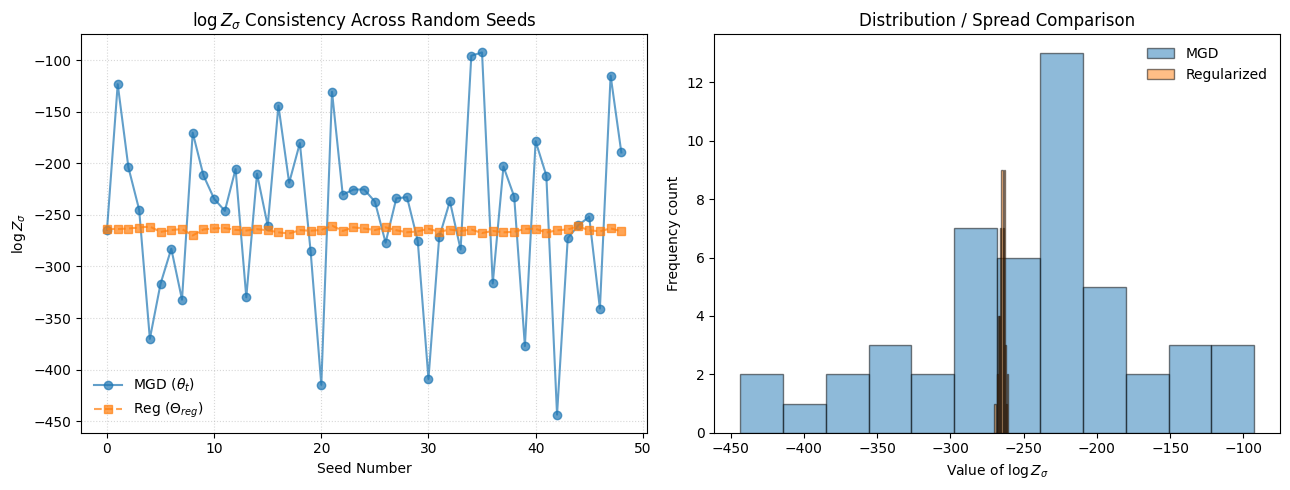

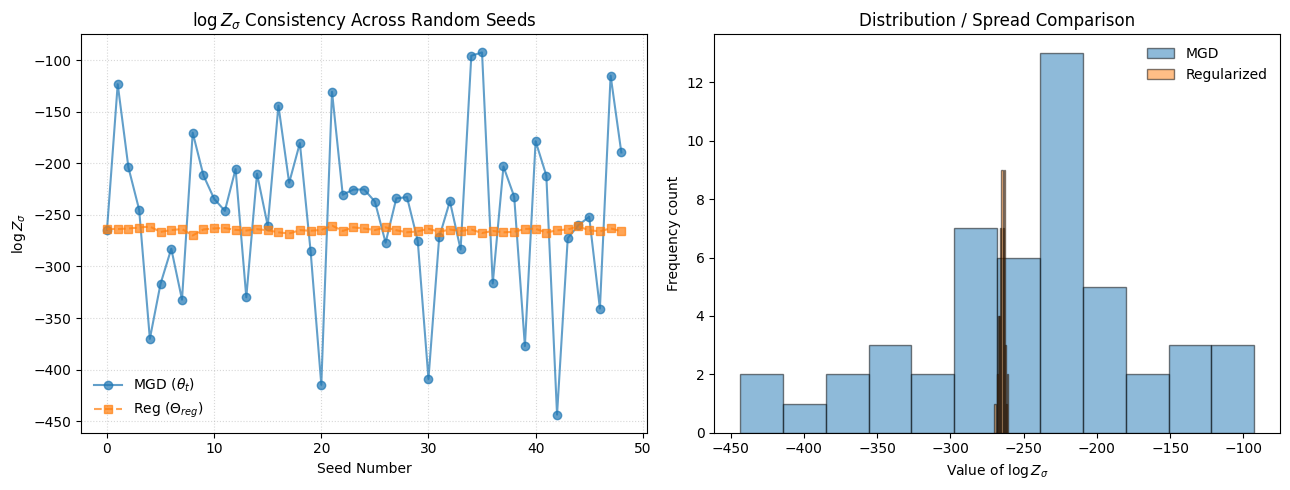

MGD Mean: -246.9173  | Std Dev: 78.1855
Reg Mean: -264.6164  | Std Dev: 1.8621


In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize collections
seed_numbers = []
logZ_mgd_list, logZ_reg_list = [], []
m1_mgd_list, m1_reg_list = [], []

# 2. Extract data safely parsing the seed integers
for key in results.keys():
    # Extract the numerical integer from "seedX" for sorting/plotting
    match = re.search(r'\d+', key)
    if not match:
        continue
    seed_idx = int(match.group())
    
    # Run your custom computation functions
    logZ_mgd, m1_mgd = compute_log_Z_sigma(x1, results, key, 'theta_t', potentials, device)
    logZ_reg, m1_reg = compute_log_Z_sigma(x1, results, key, 'Theta_reg', potentials, device)
    
    # Standard tensor-to-scalar conversions
    to_num = lambda x: x.detach().cpu().item() if isinstance(x, torch.Tensor) else float(x)
    to_num_m1 = lambda x: x.detach().cpu().norm().item() if isinstance(x, torch.Tensor) and x.ndim > 0 else to_num(x)
    
    seed_numbers.append(seed_idx)
    logZ_mgd_list.append(to_num(logZ_mgd))
    logZ_reg_list.append(to_num(logZ_reg))
    m1_mgd_list.append(to_num_m1(m1_mgd))
    m1_reg_list.append(to_num_m1(m1_reg))

# Sort everything by seed number so the plot runs sequentially
order = np.argsort(seed_numbers)
seeds_sorted = np.array(seed_numbers)[order]
logZ_mgd_arr = np.array(logZ_mgd_list)[order]
logZ_reg_arr = np.array(logZ_reg_list)[order]

# 3. Plotting for Variance & Consistency Assessment
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Sequential check across individual seeds
axes[0].plot(seeds_sorted, logZ_mgd_arr, 'o-', color='tab:blue', alpha=0.7, label=r'MGD ($\theta_t$)')
axes[0].plot(seeds_sorted, logZ_reg_arr, 's--', color='tab:orange', alpha=0.7, label=r'Reg ($\Theta_{reg}$)')
axes[0].set_xlabel('Seed Number')
axes[0].set_ylabel(r'$\log Z_\sigma$')
axes[0].set_title(r'$\log Z_\sigma$ Consistency Across Random Seeds')
axes[0].grid(True, ls=':', alpha=0.5)
axes[0].legend(frameon=False)

# Subplot 2: Distribution density to check variance/spread
axes[1].hist(logZ_mgd_arr, bins=12, alpha=0.5, color='tab:blue', label='MGD', edgecolor='black')
axes[1].hist(logZ_reg_arr, bins=12, alpha=0.5, color='tab:orange', label='Regularized', edgecolor='black')
axes[1].set_xlabel(r'Value of $\log Z_\sigma$')
axes[1].set_ylabel('Frequency count')
axes[1].set_title('Distribution / Spread Comparison')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()
%matplotlib inline 
# Quick summary statistics check printout
print(f"MGD Mean: {logZ_mgd_arr.mean():.4f}  | Std Dev: {logZ_mgd_arr.std():.4f}")
print(f"Reg Mean: {logZ_reg_arr.mean():.4f}  | Std Dev: {logZ_reg_arr.std():.4f}")

In [ ]:
logZ_mgd_arr.mean():.4f}  | Std Dev: {logZ_mgd_arr.std():.4f}")
print(f"Reg Mean: {logZ_reg_arr.mean():.4f}  | Std Dev: {logZ_reg_arr.std():.4f}")

In [17]:
# 1. Initialize collections
seed_numbers = []
negentropy_list = []
H_finals_list = []

# Dynamically locate 't' and 'nt' from your environment if they aren't inside the results dict
global_t = locals().get('t', globals().get('t', None))
global_nt = locals().get('nt', globals().get('nt', None))

# 2. Extract and compute negentropy across all seed runs
for key, res in results.items():
    # Safely parse the integer out of "seedX"
    match = re.search(r'\d+', key)
    if not match:
        continue
    seed_idx = int(match.group())
    
    dH_t_bound = res['dH_t_bound']
    
    # Use the saved time array if available; otherwise, drop back to the global timeline
    t_used = res.get('t', global_t)
    if t_used is None:
        raise ValueError(f"Time tensor 't' not found in results['{key}'] or your current workspace.")
    
    # Reuse your structural function (passing x1 as your reference tensor)
    H_p_0, H_final, d = _entropy_bound_beforefinal(
        x_ref=x1, 
        dH_t_bound=dH_t_bound, 
        t_used=t_used, 
        nt=global_nt, 
        last_point=1
    )
    
    # Compute Negentropy: ΔH_σ* = H(p_0) - H_σ*
    negentropy_val = H_p_0 - H_final
    
    seed_numbers.append(seed_idx)
    negentropy_list.append(negentropy_val)
    H_finals_list.append(H_final)

# Sort arrays by seed number for cleaner sequential visualization
order = np.argsort(seed_numbers)
seeds_sorted = np.array(seed_numbers)[order]
negentropy_arr = np.array(negentropy_list)[order]

# Calculate statistical observables over the seed distribution
neg_mean = negentropy_arr.mean()
neg_std = negentropy_arr.std()

# 3. Plotting Consistency Profiles
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: Value vs Seed Number with a 1-sigma standard deviation band
axes[0].plot(seeds_sorted, negentropy_arr, 'o-', color='tab:blue', alpha=0.7, label=r'Seed Estimate ($\Delta H_*^\sigma$)')
axes[0].axhline(y=neg_mean, color='tab:red', ls='--', alpha=0.8, label=f'Mean ({neg_mean:.4f})')
axes[0].fill_between(seeds_sorted, neg_mean - neg_std, neg_mean + neg_std, color='tab:red', alpha=0.1, label=r'$\pm 1$ Std Dev')
axes[0].set_xlabel('Seed Number')
axes[0].set_ylabel(r'Negentropy $\Delta H_*^\sigma$')
axes[0].set_title('Negentropy Stability Across Seeds')
axes[0].grid(True, ls=':', alpha=0.5)
axes[0].legend(frameon=False)

# Right plot: Frequency density to visualize distribution geometry
axes[1].hist(negentropy_arr, bins=12, alpha=0.6, color='tab:blue', edgecolor='black')
axes[1].axvline(x=neg_mean, color='tab:red', ls='--')
axes[1].set_xlabel(r'Negentropy Value ($\Delta H_*^\sigma$)')
axes[1].set_ylabel('Frequency Count')
axes[1].set_title('Distribution of Estimates')
axes[1].grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Print Summary Metrics
print(f"=== STATISTICAL OBSERVABLES OVER {len(negentropy_arr)} SEEDS ===")
print(f"Mean Negentropy : {neg_mean:.4f}")
print(f"Std Deviation   : {neg_std:.4f}")
print(f"Relative Spread : {(neg_std / abs(neg_mean)) * 100:.3f}%")

=== STATISTICAL OBSERVABLES OVER 49 SEEDS ===
Mean Negentropy : 917.8622
Std Deviation   : 0.7173
Relative Spread : 0.078%


In [18]:
print(logZ_mgd, logZ_reg) 

-189.45510864257812 -265.8766174316406
